In [3]:
import zipfile
from pathlib import Path
from astropy.io import fits
import re
import matplotlib.pyplot as plt
import numpy as np
import pyphot
from pyphot import UnitFilter
import pandas as pd

In [4]:
# Theoretical lines
def fit_lines(feh,offset=0.13):
    """Theoretical iso-metallicity lines for (CaHK-g) - bf*(g-i) vs (g-i)
    """

    Pris={}
    Pris['g_0-i_0'] = np.array([0., 0.2, 0.4, 0.6, 0.8, 1., 1.2, 1.4])
    
    #plot from theoretical curves (a bit arbitrarily offset)
    xrel = np.arange(100)*0.013 + 0.2

    if feh=='no-met':
        # for no-metal giants
        fit = 2.03002*0.488534**xrel-1.79839-0.05
    elif feh==-3.0:
        # for -3
        fit = 1.440770*0.425375**xrel-1.26330
    elif feh==-2.0:
        # for -2
        fit = 0.743684*0.164704**xrel-0.532411
    elif feh==-1.0:
        # for -1
        fit = 0.702992*0.551783**xrel-0.537230

    #Fit polynomials to the curves
    #g-i
    fit = fit+offset

    curve = np.polyfit(xrel, fit, 4)
    f_curve = np.poly1d(curve)
    x_curve = np.linspace(0.2, Pris['g_0-i_0'].max(), 50) 
    y_curve = f_curve(x_curve)

    return x_curve,y_curve

In [5]:
# Define root directory for filters
root_dir = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/AMBRE')
root_filt = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/filter')
# Name of the filters gives has the following form and gives useful data
pattern = re.compile(r'[a-zA-Z_]*[psPS](\d+)g([0-9.]+)z([-\d.]+)')


In [6]:
# Get filters
g_filter = root_filt/'SLOAN_SDSS.g.dat'
i_filter = root_filt/'SLOAN_SDSS.i.dat'
r_filter = root_filt/'SLOAN_SDSS.r.dat'
CaHK_filter = root_filt/'CaHK_trans.txt'


In [7]:
# Get wavelength and transmission values from the filters
wl_g, tx_g =np.loadtxt(g_filter, unpack=True)
wl_i, tx_i = np.loadtxt(i_filter, unpack=True)
wl_r, tx_r = np.loadtxt(r_filter, unpack=True)
wl_cahk, tx_cahk =  np.loadtxt(CaHK_filter, usecols=(0, 2), unpack=True)

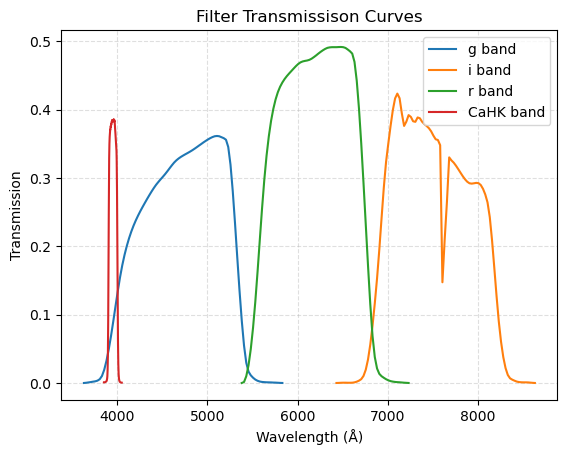

In [8]:
# Plot filters
plt.plot(wl_g, tx_g, label ='g band')
plt.plot(wl_i, tx_i, label ='i band')
plt.plot(wl_r, tx_r, label ='r band')
plt.plot(wl_cahk, tx_cahk, label ='CaHK band')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Transmission')
plt.title('Filter Transmissison Curves')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

In [ ]:
# UnitFitler to be able to calculate the flux from each filters
f_g = UnitFilter(wl_g, tx_g, name='my_g', unit='AA', dtype='photon')
f_i = UnitFilter(wl_i, tx_i, name='my_i', unit='AA', dtype='photon')
f_r = UnitFilter(wl_r, tx_r, name='my_r', unit='AA', dtype='photon')
f_cahk = UnitFilter(wl_cahk, tx_cahk, name='my_CaHK', unit='AA', dtype='photon')

# Zero point from AB system from the SVO Filter profile service
zeropoint_g = 4.92255e-9	
zeropoint_i = 1.94038e-9	
zeropoint_r = 2.85425e-9	
zeropoint_Ca = 6.96645e-9 

lib = pyphot.get_library()

gi_list = []
gr_list = []
CaHKg_list = []
feh_list = [] 

nb_spectra = 0
    
# Run over all the zip files
for outer_zip in root_dir.glob('*.zip'):
    print(f"Processing outer ZIP: {outer_zip.name}")
    
    with zipfile.ZipFile(outer_zip, 'r') as outer:
        for inner_name in outer.namelist():
            if not inner_name.endswith('.zip'):
                continue
            
            with outer.open(inner_name) as inner_zip_bytes:
                with zipfile.ZipFile(inner_zip_bytes) as inner:
                    for fits_name in inner.namelist():
                        fits_name = fits_name.strip()
                        if not fits_name.endswith('.FITS'):
                            continue
                        
                        with inner.open(fits_name) as f:
                            # Get spectrum and wavelength
                            hdul = fits.open(f)
                            table = hdul[1].data  
                            wavelength = table['wavelength']
                            flux = table['flux']

                            # Calculate flux filters
                            flux_g = f_g.get_flux(wavelength, flux, axis=1)
                            flux_i = f_i.get_flux(wavelength, flux, axis=1)
                            flux_r = f_r.get_flux(wavelength, flux, axis=1)
                            flux_cahk = f_cahk.get_flux(wavelength, flux, axis=1)

                            # Calculate magnitude 
                            
                            mag_g = -2.5 * np.log10(flux_g.magnitude / zeropoint_g)
                            mag_i =  -2.5 * np.log10(flux_i.magnitude / zeropoint_i)
                            mag_r =  -2.5 * np.log10(flux_r.magnitude / zeropoint_r)
                            mag_cahk =  -2.5 * np.log10(flux_cahk.magnitude / zeropoint_Ca)

                            gi = mag_g - mag_i
                            gr = mag_g - mag_r
                            CaHKg = mag_cahk - mag_g

                            #add to list
                            gi_list.append(gi)
                            gr_list.append(gr)
                            CaHKg_list.append(CaHKg)

                            hdul.close()
                        match = pattern.search(fits_name)
                        if match:
                            nb_spectra += 1
                            feh_list.append(float(match.group(3)))
                        else:
                            print("Skipped FITS with unexpected name:", fits_name)


print("Spectra with extracted stellar parameters:", nb_spectra)

Processing outer ZIP: AMBRE_-5.0.zip
Processing outer ZIP: AMBRE_-1.5.zip
Processing outer ZIP: AMBRE_-3.0.zip
Processing outer ZIP: AMBRE_+0.0.zip
Processing outer ZIP: AMBRE_-1.0.zip
Processing outer ZIP: AMBRE_-2.5.zip
Processing outer ZIP: AMBRE_-4.0.zip
Processing outer ZIP: AMBRE_-0.5.zip
Processing outer ZIP: AMBRE_-2.0.zip
Spectra with extracted stellar parameters: 2647


In [9]:
#load data
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')
feh_list = df['feh'].tolist()

gi_list = df['giS'].tolist()
gr_list = df['grS'].tolist()
CaHKg_list = df['CaHKgS'].tolist()

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

In [10]:
# Prepare data from loaded file
gi = np.array(gi_list)
gr = np.array(gr_list)
y_axis = np.array(CaHKg_list-1.5*gi)
CaHKg = np.array(CaHKg_list)

feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

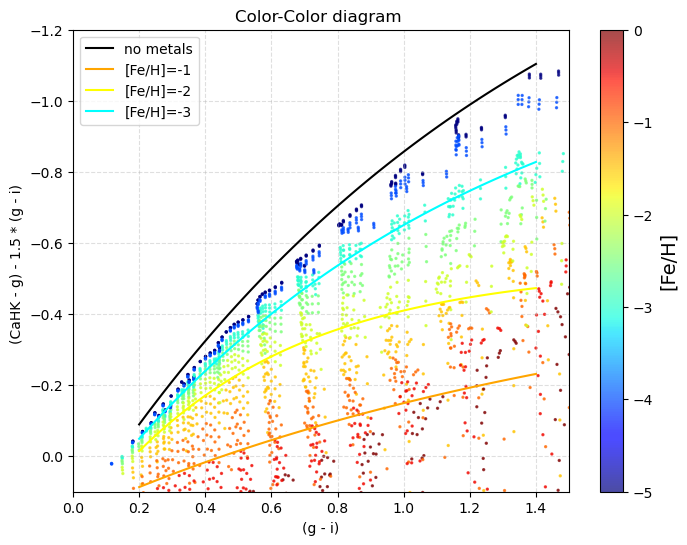

In [12]:
# Plot pseudo color-color diagram for SDSS
plt.figure(figsize=(8,6))
sc = plt.scatter(gi,y_axis, c=feh_list, cmap='jet', s=2, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel('(g - i)')
plt.ylabel('(CaHK - g) - 1.5 * (g - i) ')
plt.title('Color-Color diagram ')
cbar = plt.colorbar(label='[Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)
plt.xlim(0,1.5)
plt.ylim(0.1,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

# Add fitmlines 
x,y = fit_lines(-3,0)
x1,y1 = fit_lines(-2,0)
x2,y2 = fit_lines(-1,0)
x3,y3 = fit_lines('no-met',0)
plt.plot(x3,y3,c='black', label='no metals')
plt.plot(x2,y2,c='orange', label='[Fe/H]=-1')
plt.plot(x1,y1, c='yellow', label='[Fe/H]=-2')
plt.plot(x,y,c='cyan', label='[Fe/H]=-3')

plt.legend()

plt.show()